# Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore') 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.optim as optim
import torch.nn.functional as F
import colorama
from colorama import Fore, Style
import kagglehub

from torchvision import models
from torchvision.models import MobileNet_V3_Large_Weights

# Import Dataset

In [2]:
# Download datasets
tomato_pepper_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
chili_path = kagglehub.dataset_download("ahmadalmahsiri/chili-plant-disease")
additional_chili_path = kagglehub.dataset_download("ravindubandara3002/chilli-plant-diseases-dataset")

# Define classes to keep
tomato_pepper_classes = {
    'Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight',
    'Tomato___Bacterial_spot', 'Tomato___Leaf_Mold',
    'Pepper,_bell___healthy', 'Pepper,_bell___Bacterial_spot'
}

chili_classes = ['Healthy', 'Leaf curl', 'Leaf spot', 'Whitefly', 'Yellowish']

# Create data directories
os.makedirs('data/train', exist_ok=True)
os.makedirs('data/valid', exist_ok=True)

# Copy tomato and bell pepper classes
for split in ['train', 'valid']:
    source_dir = os.path.join(tomato_pepper_path, 'New Plant Diseases Dataset(Augmented)', 
                               'New Plant Diseases Dataset(Augmented)', split)
    if os.path.exists(source_dir):
        for class_name in tomato_pepper_classes:
            src = os.path.join(source_dir, class_name)
            dst = os.path.join(f'data/{split}', class_name)
            if os.path.exists(src):
                if os.path.exists(dst):
                    shutil.rmtree(dst)
                shutil.copytree(src, dst)

# Copy chili classes
chili_splits = {'train': 'train', 'val': 'valid'}
for chili_split, our_split in chili_splits.items():
    chili_split_dir = os.path.join(chili_path, 'Chili_Plant_Disease', chili_split)
    if os.path.exists(chili_split_dir):
        for class_name in chili_classes:
            for name_variant in [class_name, class_name.replace(' ', '_'), class_name.replace(' ', '-'),
                                class_name.lower(), class_name.lower().replace(' ', '_')]:
                src = os.path.join(chili_split_dir, name_variant)
                if os.path.exists(src):
                    dst = os.path.join(f'data/{our_split}', f'Chili___{class_name.replace(" ", "_")}')
                    if os.path.exists(dst):
                        shutil.rmtree(dst)
                    shutil.copytree(src, dst)
                    break

# Copy additional chili dataset 
additional_chili_mapping = {
    'Healthy': 'Chilli___healthy',
    'Leaf curl': 'Chilli__Leaf_Curl_Virus',
    'Leaf spot': 'Chilli__Leaf_Spot',
    'Whitefly': 'Chilli __Whitefly',
    'Yellowish': 'Chilli __Yellowish'
}

chili_dataset_path = os.path.join(additional_chili_path, 'Chilli Plant Diseases Dataset(Augmented)', 
                                   'Chilli Plant Diseases Dataset')

for our_class, dataset_class in additional_chili_mapping.items():
    for split, our_split in [('train', 'train'), ('valid', 'valid')]:
        source_dir = os.path.join(chili_dataset_path, split, dataset_class)
        
        if os.path.exists(source_dir):
            target_name = f'Chili___{our_class.replace(" ", "_")}'
            target_dir = os.path.join(f'data/{our_split}', target_name)
            
            # Copy images directly (append to existing folder)
            os.makedirs(target_dir, exist_ok=True)
            for img_file in os.listdir(source_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src = os.path.join(source_dir, img_file)
                    dst = os.path.join(target_dir, f"extra_{img_file}")
                    shutil.copy2(src, dst)

print("All datasets loaded successfully")

All datasets loaded successfully


# Exploratory Data Analysis

In [3]:
# Data directories
train_dir = 'data/train'
valid_dir = 'data/valid'

In [4]:
# Dataset overview
train_classes = sorted(os.listdir('data/train'))
total_train_images = sum(len(os.listdir(f'data/train/{cls}')) for cls in train_classes)
total_valid_images = sum(len(os.listdir(f'data/valid/{cls}')) for cls in os.listdir('data/valid'))

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nNumber of Classes: {len(train_classes)}")
print(f"\nClass Names:")
for i, cls in enumerate(train_classes, 1):
    print(f"  {i:2d}. {cls}")
print(f"\nTotal Training Images: {total_train_images:,}")
print(f"Total Validation Images: {total_valid_images:,}")
print(f"Total Images: {total_train_images + total_valid_images:,}")

DATASET OVERVIEW

Number of Classes: 12

Class Names:
   1. Chili___Healthy
   2. Chili___Leaf_curl
   3. Chili___Leaf_spot
   4. Chili___Whitefly
   5. Chili___Yellowish
   6. Pepper,_bell___Bacterial_spot
   7. Pepper,_bell___healthy
   8. Tomato___Bacterial_spot
   9. Tomato___Early_blight
  10. Tomato___Late_blight
  11. Tomato___Leaf_Mold
  12. Tomato___healthy

Total Training Images: 17,147
Total Validation Images: 3,749
Total Images: 20,896


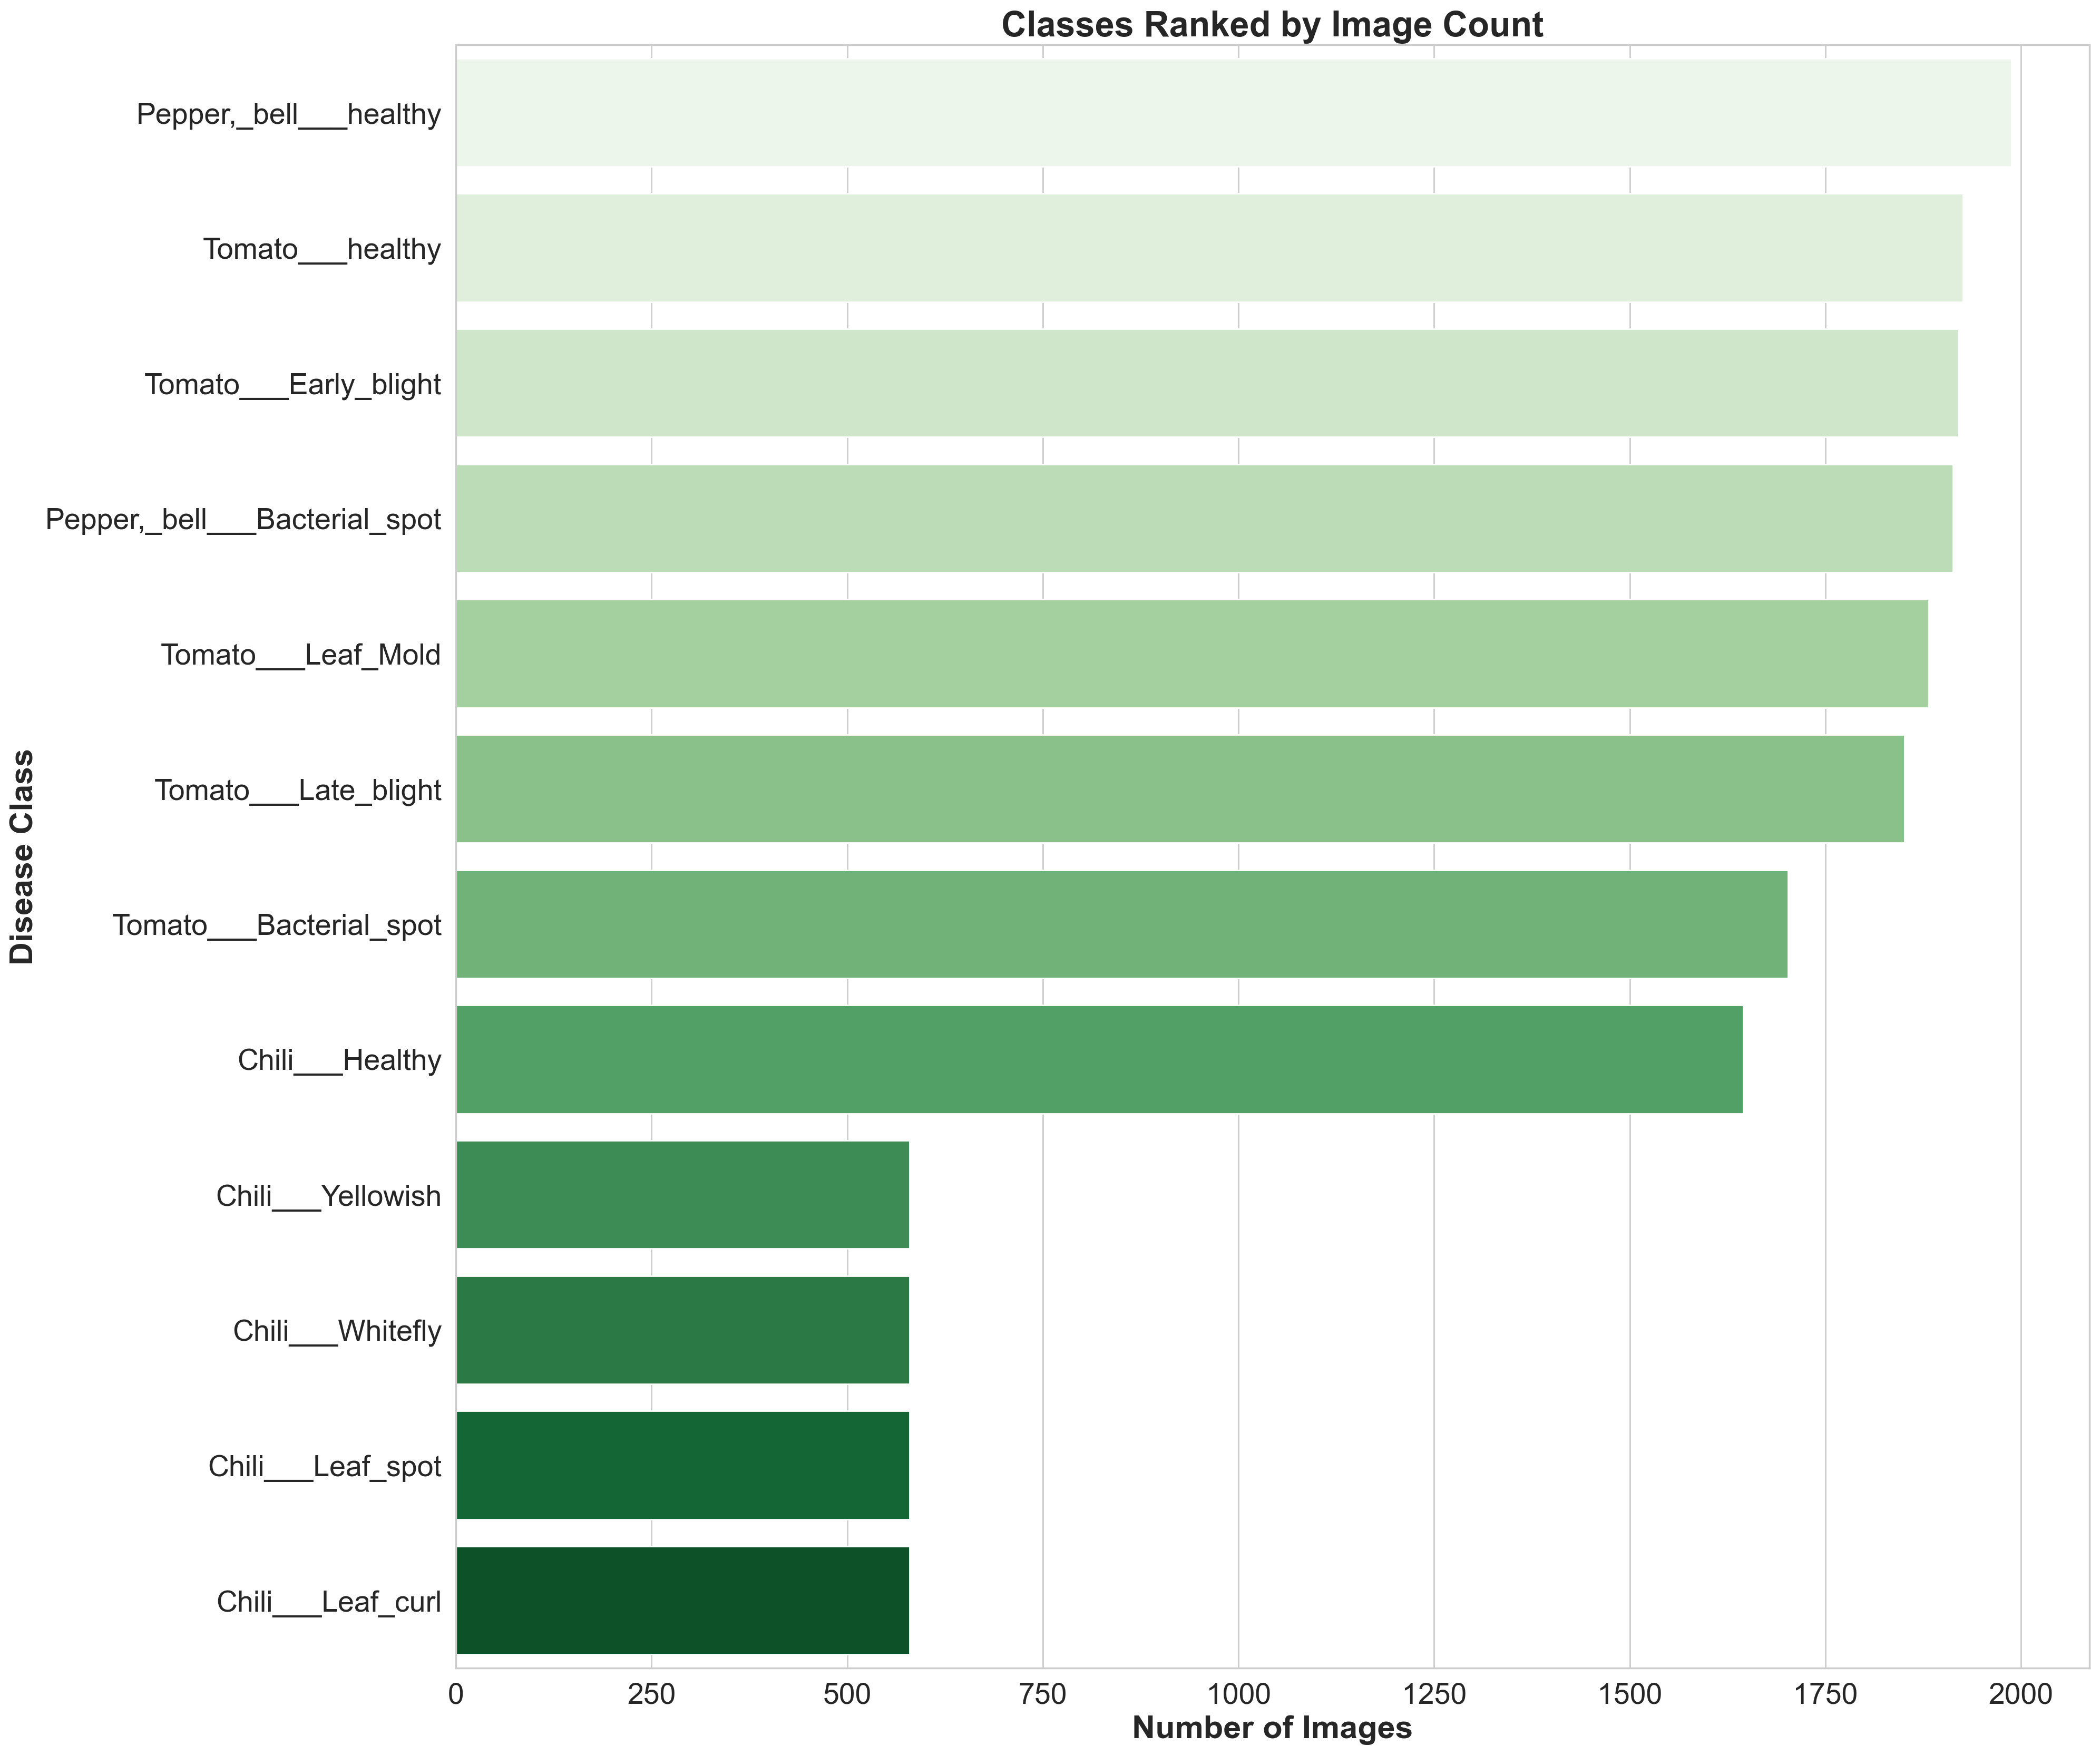

In [5]:
# Comparing the Number of Classes
plant_names = []
Len = []
for i in train_classes:
    plant_names.append(i)
    imgs_path = os.listdir(train_dir + "/" + i)
    Len.append(len(imgs_path))

# Sort both lists by image count (descending)
sorted_data = sorted(zip(Len, plant_names), reverse=True)
Len, plant_names = zip(*sorted_data)

sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(20,20), dpi=200)
ax = sns.barplot(x=list(Len), y=list(plant_names), palette="Greens")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Number of Images', fontsize=22, fontweight='bold')
plt.ylabel('Disease Class', fontsize=22, fontweight='bold')
plt.title('Classes Ranked by Image Count', fontsize=24, fontweight='bold')
plt.show()

In [6]:
# Dataset split ratio
print(f"Dataset Split: {total_train_images/(total_train_images+total_valid_images)*100:.1f}% Train / {total_valid_images/(total_train_images+total_valid_images)*100:.1f}% Valid")

Dataset Split: 82.1% Train / 17.9% Valid


# Data Preprocessing

In [7]:
target_size = (224, 224)

# Define the sequence of transformations
preprocess = transforms.Compose([
    transforms.Resize(target_size), 
    transforms.ToTensor(),          
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Load datasets with proper transforms
train = ImageFolder(train_dir, transform=preprocess)
valid = ImageFolder(valid_dir, transform=preprocess)

In [8]:
train

Dataset ImageFolder
    Number of datapoints: 17147
    Root location: data/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [9]:
train[0]

(tensor([[[ 0.5364,  0.0912, -0.5082,  ...,  0.0741,  0.5022,  0.3138],
          [ 0.5022,  0.3652, -0.1828,  ...,  0.3481,  0.6392,  0.5022],
          [ 0.5878,  0.5364,  0.2453,  ...,  0.6392,  0.6906,  0.6392],
          ...,
          [ 0.3481,  0.1254, -0.3712,  ..., -0.1143, -0.2342, -0.1657],
          [ 0.1939, -0.0458, -0.4226,  ...,  0.0569, -0.1828, -0.1999],
          [-0.3369, -0.7137, -0.7650,  ..., -0.0972, -0.4054, -0.3883]],
 
         [[ 1.5357,  1.0980,  0.5203,  ..., -1.0378, -0.0749, -0.0574],
          [ 1.5182,  1.3957,  0.8529,  ..., -0.6702,  0.1176,  0.1702],
          [ 1.6408,  1.5882,  1.3081,  ..., -0.2500,  0.2752,  0.3627],
          ...,
          [ 0.7304,  0.6429,  0.3627,  ..., -0.4601, -0.5651, -0.4776],
          [ 0.5728,  0.4678,  0.3102,  ..., -0.2850, -0.5126, -0.4951],
          [ 0.0301, -0.2150, -0.0399,  ..., -0.4426, -0.7402, -0.6877]],
 
         [[ 0.7925,  0.3045, -0.3404,  ..., -0.4275,  0.4439,  0.4265],
          [ 0.6705,  0.4962,

In [10]:
train[7000]

(tensor([[[0.3823, 0.4166, 0.4166,  ..., 0.4679, 0.5193, 0.5536],
          [0.3652, 0.3994, 0.3994,  ..., 0.5022, 0.5364, 0.5364],
          [0.3994, 0.4679, 0.4679,  ..., 0.4679, 0.4679, 0.4337],
          ...,
          [0.8104, 0.9303, 0.9646,  ..., 0.9817, 1.1187, 1.1015],
          [0.9474, 0.9474, 0.8961,  ..., 0.9132, 0.9988, 1.0844],
          [1.0159, 0.8789, 0.7762,  ..., 1.3070, 1.3242, 1.1187]],
 
         [[0.2402, 0.2752, 0.2752,  ..., 0.3978, 0.4503, 0.4853],
          [0.2227, 0.2577, 0.2577,  ..., 0.4328, 0.4678, 0.4678],
          [0.2577, 0.3277, 0.3277,  ..., 0.3978, 0.3978, 0.3627],
          ...,
          [0.7654, 0.8880, 0.9230,  ..., 1.0105, 1.1506, 1.1331],
          [0.9055, 0.9055, 0.8529,  ..., 0.9405, 1.0280, 1.1155],
          [0.9755, 0.8354, 0.7304,  ..., 1.3431, 1.3606, 1.1506]],
 
         [[0.4788, 0.5136, 0.5136,  ..., 0.6879, 0.7402, 0.7751],
          [0.4614, 0.4962, 0.4962,  ..., 0.7228, 0.7576, 0.7576],
          [0.4962, 0.5659, 0.5659,  ...,

In [11]:
img, label = train[0]
print(img.shape, label)

torch.Size([3, 224, 224]) 0



Label: Chili___Healthy (0)

Label: Chili___Healthy (0)

Label: Chili___Whitefly (3)

Label: Pepper,_bell___Bacterial_spot (5)

Label: Tomato___Bacterial_spot (7)

Label: Tomato___Early_blight (8)

Label: Tomato___Late_blight (9)

Label: Tomato___Leaf_Mold (10)


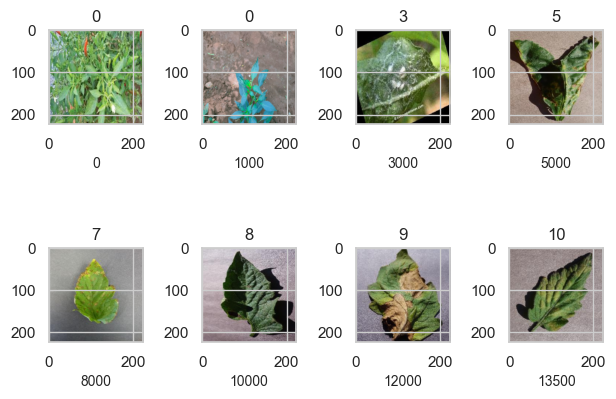

In [12]:
def show_image(image, label):
    """Display image with denormalization"""
    # Denormalize the image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    denormalized = image * std + mean
    
    # Clamp values to [0, 1] range
    denormalized = torch.clamp(denormalized, 0, 1)
    
    print("Label: " + train.classes[label] + " (" + str(label) + ")")
    plt.imshow(denormalized.permute(1, 2, 0))
    
# Use valid indices within dataset range 
image_list = [0, 1000, 3000, 5000, 8000, 10000, 12000, 13500]
    
chs = 0
for img in image_list:
    chs += 1
    plt.subplot(2, 4, chs)
    print(Fore.GREEN)
    plt.tight_layout()
    plt.xlabel(img, fontsize=10)
    plt.title(train[img][1])
    show_image(*train[img])

In [13]:
batch_size = 32

# DataLoaders for training and validation
train_dataloader = DataLoader(train, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dataloader = DataLoader(valid, batch_size, num_workers=2, pin_memory=True)

# Device of Process

In [14]:
# for moving data into GPU (if available)
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

In [15]:
# for moving data to device (CPU or GPU)
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [16]:
# for loading in the device (GPU if available else CPU)
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dataloader:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dataloader)

In [17]:
device = get_default_device()
device

device(type='cuda')

In [18]:
# Moving data into GPU, WrappedDataLoader
train_dataloader = DeviceDataLoader(train_dataloader, device)
valid_dataloader = DeviceDataLoader(valid_dataloader, device)

# CNN (MobileNetV3)

In [19]:
weights = MobileNet_V3_Large_Weights.DEFAULT
model = models.mobilenet_v3_large(weights=weights)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier for 12 disease classes
num_classes = len(train.classes)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

# Move model to device
model = to_device(model, device)

print(f"Model: MobileNetV3-Large")
print(f"Classes: {num_classes}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model: MobileNetV3-Large
Classes: 12
Total parameters: 4,217,404
Trainable parameters: 15,372


# Training & Evaluation

In [20]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

print(f"Training on: {device}")
print(f"Epochs: {num_epochs}, Batch size: {batch_size}, Learning rate: 0.001")

Training on: cuda
Epochs: 10, Batch size: 32, Learning rate: 0.001


In [21]:
# Evaluation function
def evaluate_model(model, dataloader, criterion):
    """Evaluate model on validation set"""
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = val_loss / len(dataloader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

In [22]:
# Training loop
history = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Calculate training loss
    train_loss = running_loss / len(train_dataloader)
    
    # Validation phase
    val_loss, val_acc = evaluate_model(model, valid_dataloader, criterion)
    
    # Store history
    history.append({
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc
    })
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("\nTraining completed!")

Epoch [1/10] - Train Loss: 0.5862, Val Loss: 0.1933, Val Acc: 95.44%
Epoch [2/10] - Train Loss: 0.2473, Val Loss: 0.1364, Val Acc: 96.27%
Epoch [3/10] - Train Loss: 0.1924, Val Loss: 0.1134, Val Acc: 96.88%
Epoch [4/10] - Train Loss: 0.1659, Val Loss: 0.0993, Val Acc: 97.25%
Epoch [5/10] - Train Loss: 0.1448, Val Loss: 0.0899, Val Acc: 97.57%
Epoch [6/10] - Train Loss: 0.1368, Val Loss: 0.0875, Val Acc: 97.52%
Epoch [7/10] - Train Loss: 0.1267, Val Loss: 0.0810, Val Acc: 97.52%
Epoch [8/10] - Train Loss: 0.1227, Val Loss: 0.0806, Val Acc: 97.57%
Epoch [9/10] - Train Loss: 0.1168, Val Loss: 0.0792, Val Acc: 97.39%
Epoch [10/10] - Train Loss: 0.1119, Val Loss: 0.0769, Val Acc: 97.55%

Training completed!


In [23]:
# Backup existing model before saving new one
import datetime

model_path = 'models/plant_disease_mobilenetv3.pth'
if os.path.exists(model_path):
    # Create backup with timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_path = f'models/plant_disease_mobilenetv3_backup_{timestamp}.pth'
    shutil.copy2(model_path, backup_path)
    print(f"✓ Existing model backed up to: {backup_path}")
else:
    print("No existing model found - will create new model")

✓ Existing model backed up to: models/plant_disease_mobilenetv3_backup_20260110_032134.pth


## Model Backup & Save

In [24]:
# Save model and class names
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train.classes,
    'num_classes': num_classes
}, 'models/plant_disease_mobilenetv3.pth')
print("Model saved to models/plant_disease_mobilenetv3.pth")
print(f"Classes saved: {train.classes}")

Model saved to models/plant_disease_mobilenetv3.pth
Classes saved: ['Chili___Healthy', 'Chili___Leaf_curl', 'Chili___Leaf_spot', 'Chili___Whitefly', 'Chili___Yellowish', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


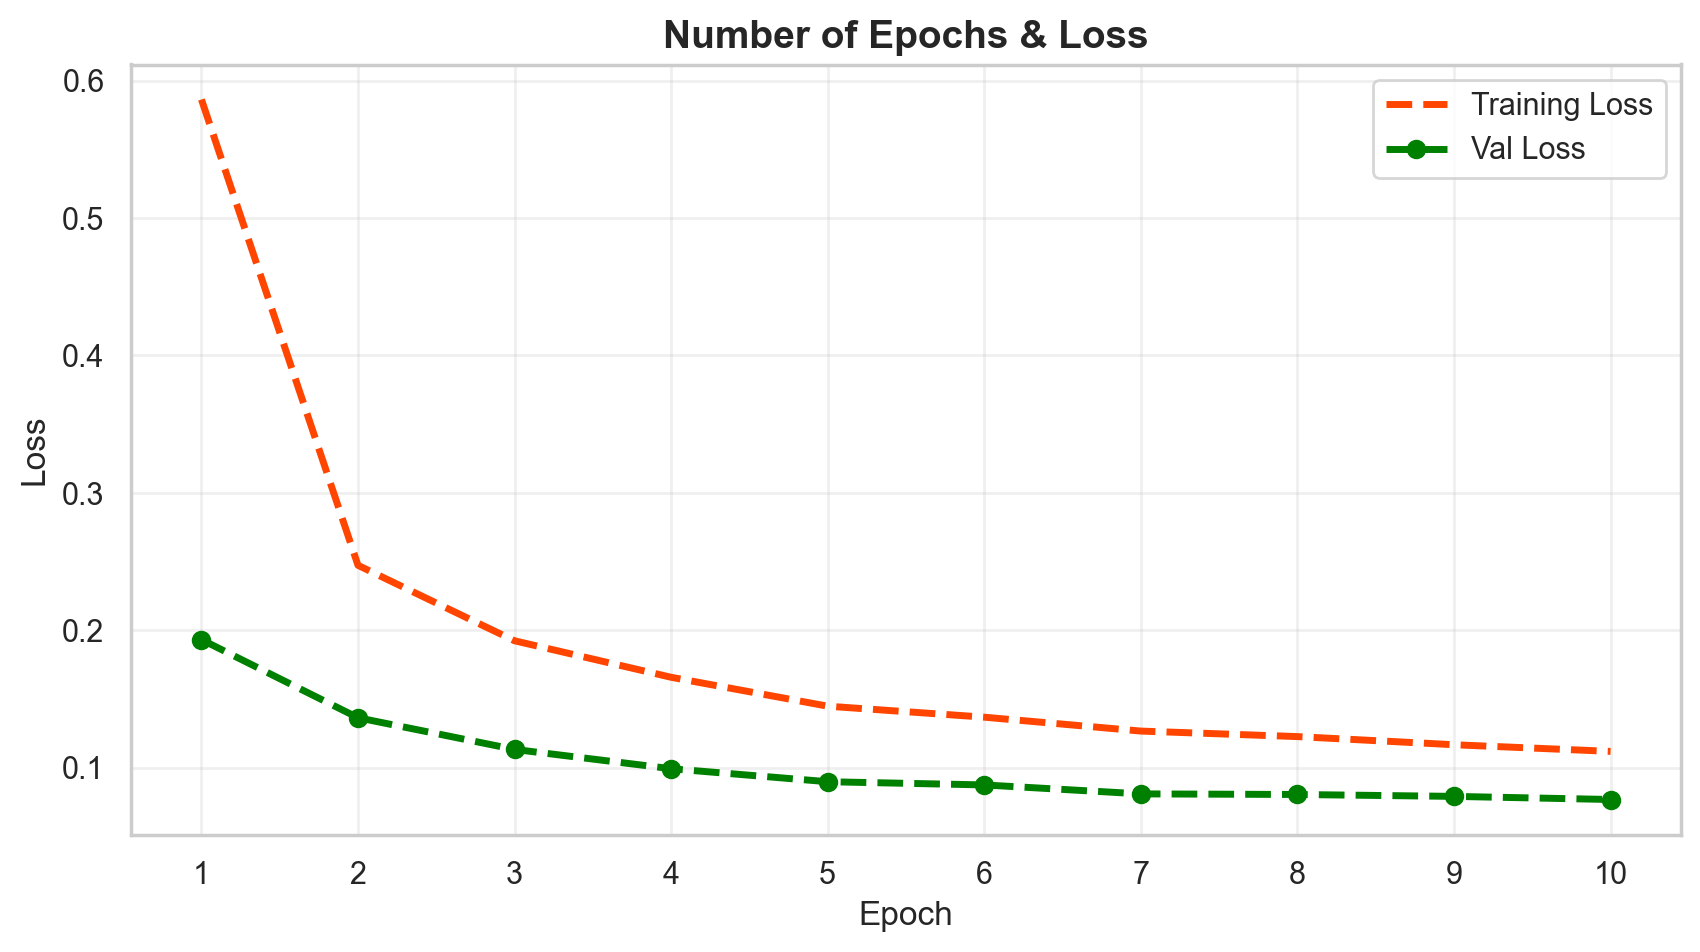

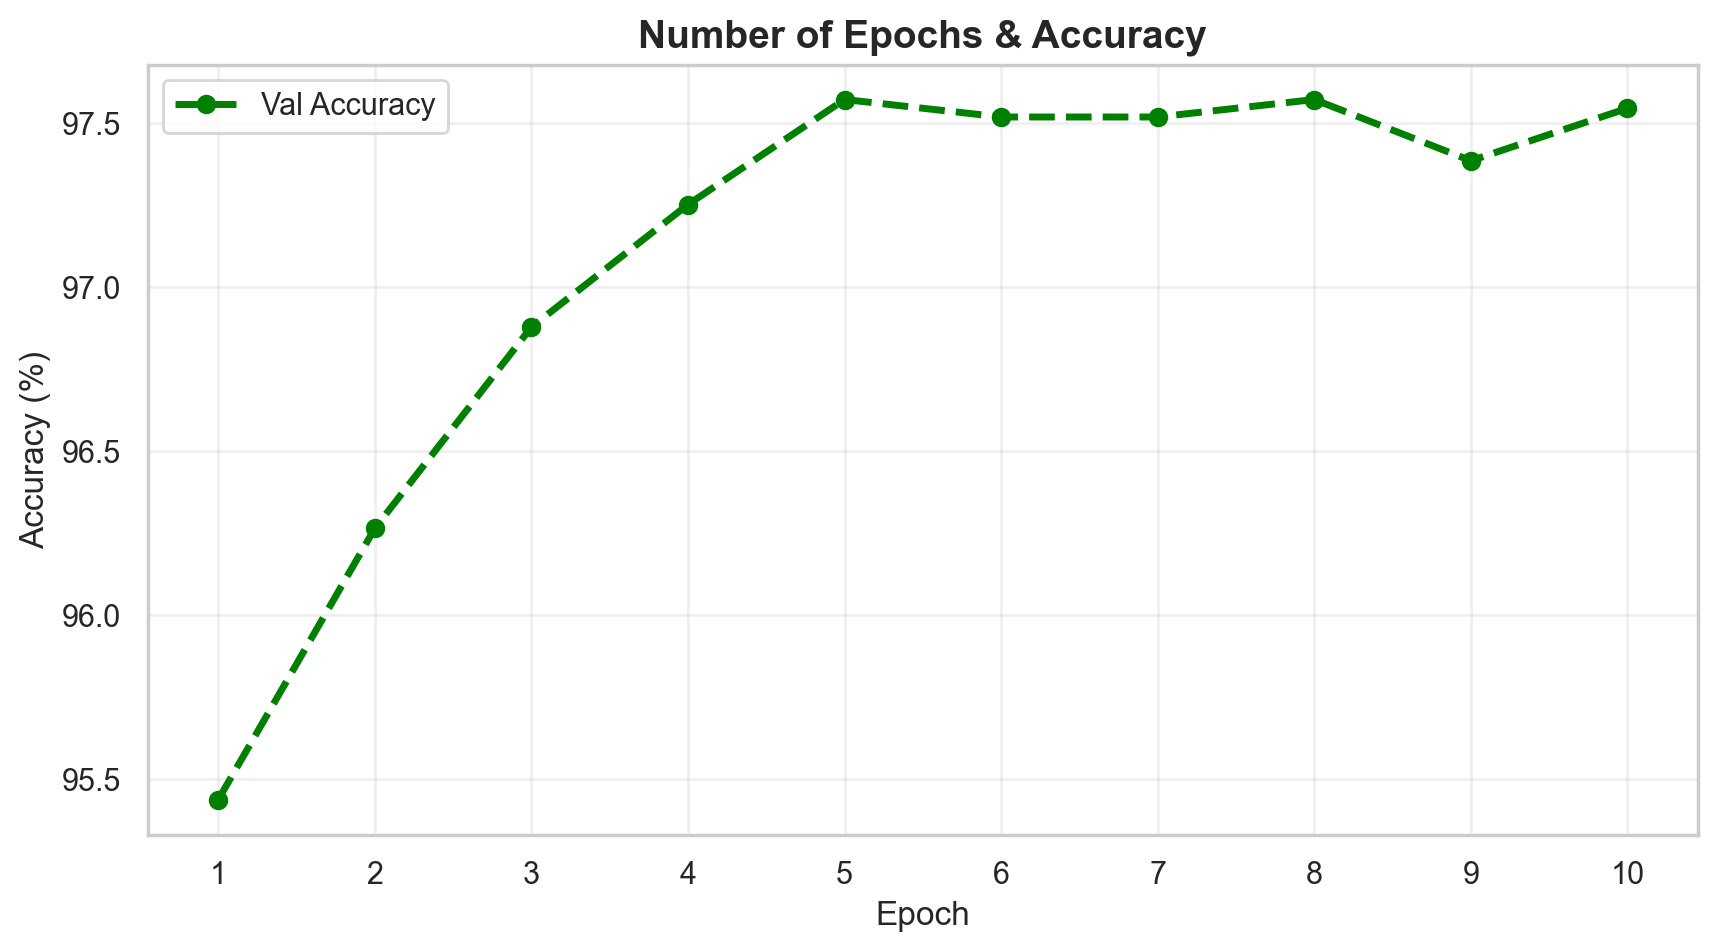


Final Results:
Train Loss: 0.1119
Val Loss: 0.0769
Val Accuracy: 97.55%


In [25]:
# Extract metrics from history
val_acc = [i['val_acc'] for i in history]
val_loss = [i['val_loss'] for i in history]
train_loss = [i['train_loss'] for i in history]

epoch_count = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(10, 5), dpi=200)
plt.plot(epoch_count, train_loss, 'r--', color='orangered', linewidth=2.5)
plt.plot(epoch_count, val_loss, '--o', color='green', linewidth=2.5)
plt.legend(['Training Loss', 'Val Loss'])
plt.title('Number of Epochs & Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(1, num_epochs + 1, 1))
plt.grid(alpha=0.3)
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5), dpi=200)
plt.plot(epoch_count, val_acc, '--o', color='green', linewidth=2.5)
plt.legend(['Val Accuracy'])
plt.title('Number of Epochs & Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(np.arange(1, num_epochs + 1, 1))
plt.grid(alpha=0.3)
plt.show()

print(f"\nFinal Results:")
print(f"Train Loss: {train_loss[-1]:.4f}")
print(f"Val Loss: {val_loss[-1]:.4f}")
print(f"Val Accuracy: {val_acc[-1]:.2f}%")